In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob as glob
import os
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn import metrics
import matplotlib.lines as mlines
import itertools
import os
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, roc_auc_score, make_scorer,
                              accuracy_score, f1_score, precision_score, recall_score)

In [ ]:

df_original = pd.read_csv("dfR_datosclusterp2C.csv")


In [45]:
df_inicial=df_original

In [46]:
df_inicial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Material                   426 non-null    object 
 1   AR_Moisturecontent         426 non-null    float64
 2   AR_Ashcontent              426 non-null    float64
 3   AR_Volatilematter          426 non-null    float64
 4   AR_Fixedcarbon             426 non-null    float64
 5   AR_Netcalorificvalue(LHV)  426 non-null    float64
 6   AR_Carbon                  426 non-null    float64
 7   AR_Hydrogen                426 non-null    float64
 8   AR_Nitrogen                426 non-null    float64
 9   AR_Sulphur                 426 non-null    float64
 10  AR_Oxygen                  426 non-null    float64
 11  cluster                    426 non-null    int64  
dtypes: float64(10), int64(1), object(1)
memory usage: 40.1+ KB


In [47]:
df_inicial.describe()

,AR_Moisturecontent,AR_Ashcontent,AR_Volatilematter,AR_Fixedcarbon,AR_Netcalorificvalue(LHV),AR_Carbon,AR_Hydrogen,AR_Nitrogen,AR_Sulphur,AR_Oxygen,cluster
count,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.00000,426.000000,426.000000,426.000000
mean,15.834225,9.071643,58.837183,16.186455,14.572324,39.846526,4.620352,0.85007,0.221479,29.472207,0.814554
std,17.120690,12.502600,18.588593,11.902826,5.164174,12.658616,1.310713,0.99315,0.321585,10.672648,1.150294
min,0.100000,0.060000,4.820000,0.600000,0.190000,6.200000,0.750000,0.02000,0.010000,0.920000,0.000000
25%,6.310000,1.352500,46.072500,11.172500,12.022500,33.225000,3.972500,0.23000,0.040000,22.232500,0.000000
50%,9.790000,4.110000,65.775000,14.220000,15.320000,42.015000,5.030000,0.52000,0.080000,34.085000,0.000000
75%,15.000000,9.417500,72.700000,16.820000,16.797500,46.247500,5.467500,1.06000,0.247500,38.057500,2.000000
max,83.700000,64.110000,85.780000,87.700000,34.340000,87.250000,8.320000,5.48000,1.990000,43.410000,3.000000


In [50]:
df_initial1 = df_inicial

In [51]:
# Select feature columns and target variable
feature_cols = [
    'AR_Moisturecontent', 'AR_Ashcontent',
    'AR_Volatilematter', 'AR_Fixedcarbon',
    'AR_Netcalorificvalue(LHV)'
]

X = df_initial1.loc[:, feature_cols].values
y = df_initial1.loc[:, ['cluster']].values.ravel()

# Split into train/test sets (stratify keeps class proportions balanced)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features (fit only on training data to avoid data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Persist the fitted scaler for later use (e.g., inference)
joblib.dump(scaler, 'scaler.pkl')

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 340  |  Test: 86


── Model Comparison ──
              Model Accuracy F1_macro Precision Recall
Logistic Regression   0.9884   0.9622    0.9808 0.9500
          SVM (RBF)   0.9767   0.9433    0.9635 0.9292
      Random Forest   1.0000   1.0000    1.0000 1.0000
  Gradient Boosting   0.9884   0.9622    0.9808 0.9500
                KNN   0.9651   0.9293    0.9571 0.9083


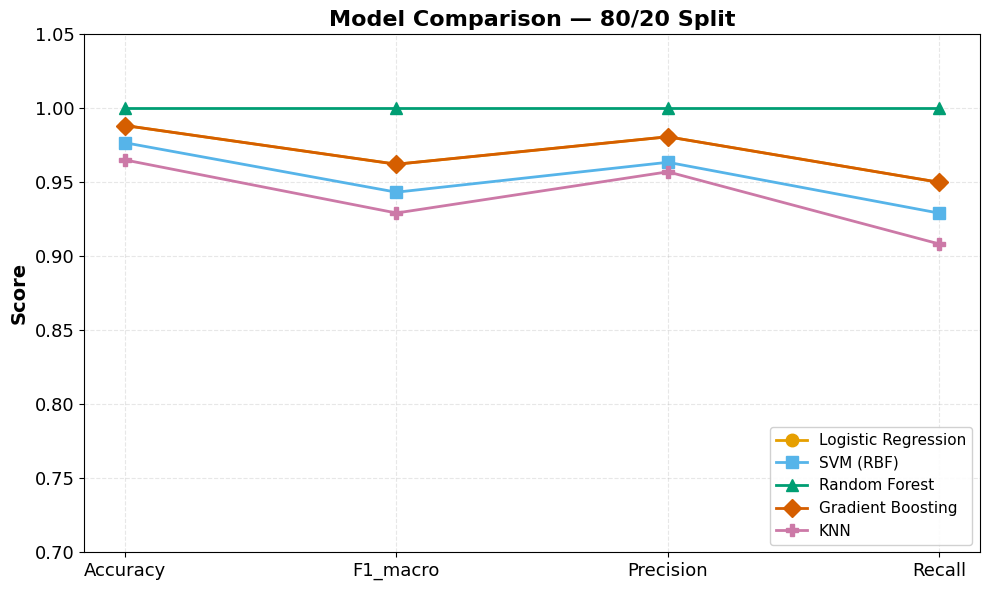

In [52]:
# ─────────────────────────────────────────
# 1. DEFINE MODELS TO COMPARE
# ─────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        solver='lbfgs', random_state=42, max_iter=1000, C=1.0),
    'SVM (RBF)': SVC(
        kernel='rbf', C=1.0, gamma='scale',
        random_state=42, probability=True),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(
        n_neighbors=5, n_jobs=-1),
}

# ─────────────────────────────────────────
# 2. TRAIN & EVALUATE ONCE, REUSE RESULTS
# X_train / X_test are already scaled
# ─────────────────────────────────────────
results = []
metrics_by_model = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    scores = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'F1_macro':  f1_score(y_test, y_pred, average='macro'),
        'Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall':    recall_score(y_test, y_pred, average='macro'),
    }
    metrics_by_model[name] = scores

    results.append({
        'Model': name,
        **{k: f"{v:.4f}" for k, v in scores.items()}
    })

df_comparison = pd.DataFrame(results)
print("── Model Comparison ──")
print(df_comparison.to_string(index=False))

# ─────────────────────────────────────────
# 3. METRICS COMPARISON CHART
# ─────────────────────────────────────────
wong_colors    = ['#E69F00', '#56B4E9', '#009E73', '#D55E00', '#CC79A7']
metrics_labels = ['Accuracy', 'F1_macro', 'Precision', 'Recall']
markers        = ['o', 's', '^', 'D', 'P']

fig, ax = plt.subplots(figsize=(10, 6))
for idx, (name, scores) in enumerate(metrics_by_model.items()):
    values = [scores[m] for m in metrics_labels]
    ax.plot(metrics_labels, values,
            color=wong_colors[idx], marker=markers[idx],
            linewidth=2, markersize=9, label=name)

ax.set_ylabel('Score', fontweight='bold', fontsize=14)
ax.set_title('Model Comparison — 80/20 Split',
             fontweight='bold', fontsize=16)
ax.set_ylim(0.7, 1.05)
ax.tick_params(axis='both', labelsize=13)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
fig.savefig('Model_Comparison_Metrics.png', dpi=300, bbox_inches='tight')
plt.show()

── Model Comparison ──
              Model        Accuracy        F1_macro       Precision          Recall
Logistic Regression 0.9765 ± 0.0149 0.9638 ± 0.0273 0.9842 ± 0.0129 0.9480 ± 0.0384
          SVM (RBF) 0.9671 ± 0.0173 0.9521 ± 0.0270 0.9652 ± 0.0228 0.9430 ± 0.0376
      Random Forest 0.9836 ± 0.0120 0.9769 ± 0.0233 0.9861 ± 0.0143 0.9703 ± 0.0304
  Gradient Boosting 0.9836 ± 0.0058 0.9657 ± 0.0186 0.9747 ± 0.0144 0.9624 ± 0.0222
                KNN 0.9741 ± 0.0188 0.9587 ± 0.0281 0.9683 ± 0.0241 0.9530 ± 0.0372


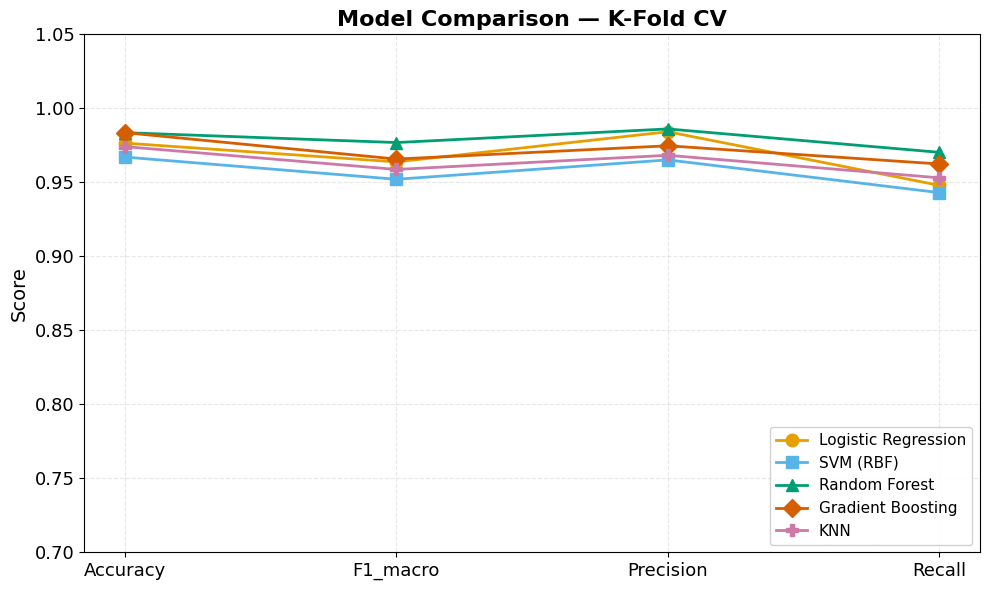

In [53]:
# ─────────────────────────────────────────
# 1. DEFINE MODELS TO COMPARE
# ─────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        solver='lbfgs', random_state=42, max_iter=1000, C=1.0),
    'SVM (RBF)': SVC(
        kernel='rbf', C=1.0, gamma='scale',
        random_state=42, probability=True),   # probability=True for ROC
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(
        n_neighbors=5, n_jobs=-1),
}
# ─────────────────────────────────────────
# 2. COMPARE WITH K-FOLD
# ─────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorers = {
    'accuracy':  make_scorer(accuracy_score),
    'f1_macro':  make_scorer(f1_score,        average='macro'),
    'precision': make_scorer(precision_score,  average='macro', zero_division=0),
    'recall':    make_scorer(recall_score,     average='macro'),
}
results = []
for name, model in models.items():
    pipeline = Pipeline([
        ('scaler',     StandardScaler()),
        ('classifier', model)
    ])
    cv_results = cross_validate(
        pipeline, X, y,
        cv=skf, scoring=scorers,
        n_jobs=-1
    )
    results.append({
        'Model':     name,
        'Accuracy':  f"{cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}",
        'F1_macro':  f"{cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}",
        'Precision': f"{cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}",
        'Recall':    f"{cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}",
    })
df_comparison = pd.DataFrame(results)
print("── Model Comparison ──")
print(df_comparison.to_string(index=False))
# ─────────────────────────────────────────
# 4. METRICS COMPARISON CHART
# ─────────────────────────────────────────
wong_colors = ['#E69F00', '#56B4E9', '#009E73', '#D55E00', '#CC79A7']
metrics_list = ['accuracy', 'f1_macro', 'precision', 'recall']
markers      = ['o', 's', '^', 'D', 'P']
fig, ax = plt.subplots(figsize=(10, 6))
for idx, (name, model) in enumerate(models.items()):
    pipeline = Pipeline([
        ('scaler',     StandardScaler()),
        ('classifier', model)
    ])
    cv_results = cross_validate(pipeline, X, y, cv=skf,
                                scoring=scorers, n_jobs=-1)
    means = [cv_results[f'test_{m}'].mean() for m in metrics_list]
    ax.plot(['Accuracy', 'F1_macro', 'Precision', 'Recall'],
            means,
            color=wong_colors[idx],
            marker=markers[idx],
            linewidth=2, markersize=9,
            label=name)
ax.set_ylabel('Score',   fontsize=14)
ax.set_title('Model Comparison — K-Fold CV',
             fontweight='bold', fontsize=16)
ax.set_ylim(0.7, 1.05)
ax.tick_params(axis='both', labelsize=13)
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join('Model_Comparison_Metrics1.png'),
            dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
file = "New_Biomass.xlsx"
df_test_data = pd.read_excel(file, engine='openpyxl')

In [57]:
df_test = df_test_data

In [58]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 186 non-null    object 
 1   AR_Moisturecontent         186 non-null    float64
 2   AR_Volatilematter          186 non-null    float64
 3   AR_Fixedcarbon             186 non-null    float64
 4   AR_Ashcontent              186 non-null    float64
 5   AR_Netcalorificvalue(LHV)  186 non-null    float64
 6   AR_Carbon                  186 non-null    float64
 7   AR_Hydrogen                186 non-null    float64
 8   AR_Nitrogen                186 non-null    float64
 9   AR_Sulphur                 186 non-null    float64
 10  AR_Oxygen                  186 non-null    float64
dtypes: float64(10), object(1)
memory usage: 16.1+ KB


In [59]:
XN = df_test.loc[:, ['AR_Moisturecontent','AR_Ashcontent','AR_Volatilematter','AR_Fixedcarbon','AR_Netcalorificvalue(LHV)']].values

In [60]:
classes= ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']


── Prediction distribution ──
cluster
1    105
0     68
2     12
3      1
Name: count, dtype: int64
── First 10 results ──
   AR_Moisturecontent  AR_Volatilematter  cluster  confidence
0                52.6               36.3        2        0.99
1                 8.4               70.9        0        1.00
2                 8.4               67.5        0        1.00
3                 8.4               71.9        0        1.00
4                37.8               46.1        2        1.00
5                 8.4               67.0        0        1.00
6                12.0               68.7        0        1.00
7                62.9               30.4        3        0.87
8                56.8               34.5        2        0.86
9                 8.4               65.9        0        1.00

── Low confidence data < 0.6 ──
  9 low confidence records
     AR_Moisturecontent  AR_Volatilematter  cluster  confidence
78                 2.50              61.00        0        0.53
85    

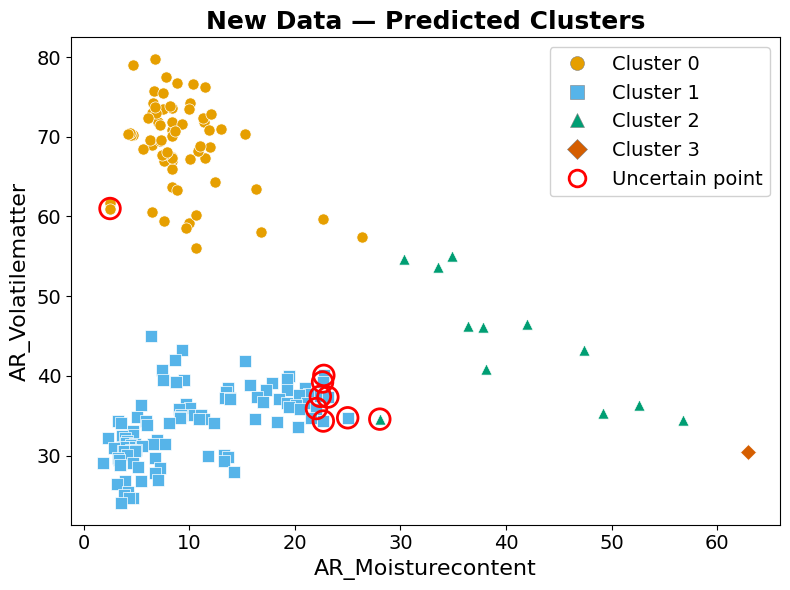

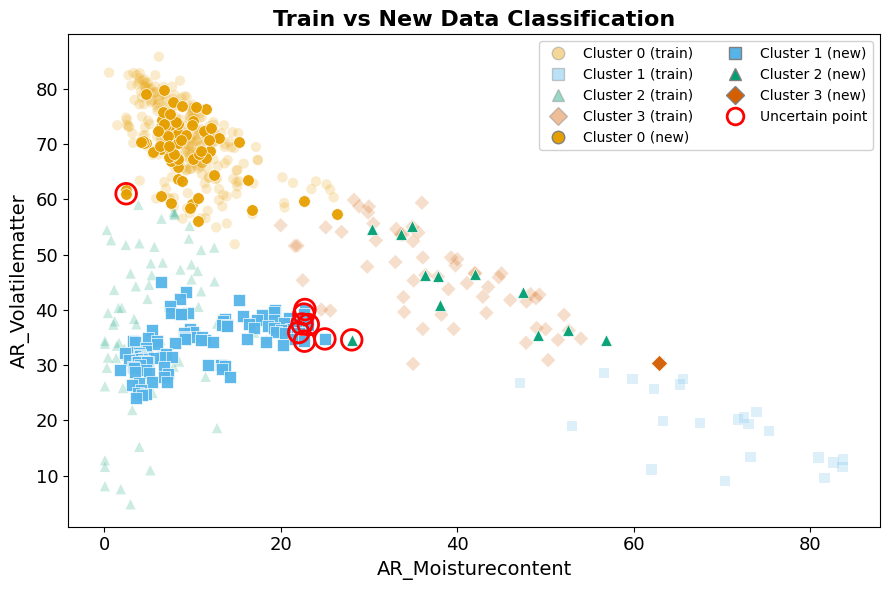


File saved: new_data_classified.csv


In [ ]:
# ─────────────────────────────────────────
# 2. PREDICT — pipeline scales automatically
# ─────────────────────────────────────────
loaded_model      = joblib.load('model_F_RF.pkl')
new_predictions      = loaded_model.predict(XN)
new_predictions_prob = loaded_model.predict_proba(XN)

# FIX: get classes directly from the loaded model, not from a stale variable
classes = loaded_model.classes_

# ─────────────────────────────────────────
# 3. RESULTS DATAFRAME
# ─────────────────────────────────────────
df_results = df_test.copy()
df_results['cluster'] = new_predictions

for i, cls in enumerate(classes):
    df_results[f'prob_cluster_{cls}'] = new_predictions_prob[:, i].round(4)

df_results['confidence'] = new_predictions_prob.max(axis=1).round(4)
print("\n── Prediction distribution ──")
print(df_results['cluster'].value_counts())


print("── First 10 results ──")
print(df_results[['AR_Moisturecontent', 'AR_Volatilematter',
                   'cluster', 'confidence']].head(10))

print("\n── Low confidence data < 0.6 ──")
low_conf = df_results[df_results['confidence'] < 0.6]
print(f"  {len(low_conf)} low confidence records")
if len(low_conf) > 0:
    print(low_conf[['AR_Moisturecontent', 'AR_Volatilematter',
                     'cluster', 'confidence']])

# ─────────────────────────────────────────
# 4. NEW DATA ONLY — with uncertainty circles
# ─────────────────────────────────────────
wong_colors = ['#E69F00', '#56B4E9', '#009E73', '#D55E00']
markers     = ['o', 's', '^', 'D']

# Uncertainty threshold: points where max probability < 0.6
UNCERTAINTY_THRESHOLD = 0.6
uncertain_mask = df_results['confidence'] < UNCERTAINTY_THRESHOLD

fig, ax = plt.subplots(figsize=(8, 6))

for idx, cls in enumerate(classes):
    mask = new_predictions == cls
    ax.scatter(XN[mask][:, 0], XN[mask][:, 2],
               c=wong_colors[idx % len(wong_colors)],
               marker=markers[idx % len(markers)],
               s=65, alpha=1, edgecolors='white', linewidths=0.5)

# Uncertainty circles — points that could belong to another cluster
for i in range(len(XN)):
    if uncertain_mask.iloc[i]:
        ax.scatter(XN[i, 0], XN[i, 2],
                   s=220, facecolors='none',
                   edgecolors='red', linewidths=2.0, zorder=5)

handles = [mlines.Line2D([], [], marker=markers[i], color='w',
               markerfacecolor=wong_colors[i], markeredgecolor='grey',
               markeredgewidth=0.4, markersize=10, label=f'Cluster {cls}')
           for i, cls in enumerate(classes)]
handles.append(mlines.Line2D([], [], marker='o', color='w',
               markerfacecolor='none', markeredgecolor='red',
               markeredgewidth=2.0, markersize=12, label='Uncertain point'))

ax.legend(handles=handles, loc='upper right', fontsize=14, framealpha=0.9)
ax.set_title('New Data — Predicted Clusters', fontsize=18, fontweight='bold')
ax.set_xlabel('AR_Moisturecontent', fontsize=16)
ax.set_ylabel('AR_Volatilematter',  fontsize=16)
ax.tick_params(axis='both', labelsize=14)
plt.tight_layout()
fig.savefig('New_data_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────
# 5. TRAIN vs NEW DATA — with uncertainty circles
# ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

# Training data (transparent)
for idx, cls in enumerate(classes):
    mask = y == cls
    ax.scatter(X[mask][:, 0], X[mask][:, 2],
               c=wong_colors[idx % len(wong_colors)],
               marker=markers[idx % len(markers)],
               s=55, alpha=0.20, edgecolors='none')

# New data (solid)
for idx, cls in enumerate(classes):
    mask = new_predictions == cls
    ax.scatter(XN[mask][:, 0], XN[mask][:, 2],
               c=wong_colors[idx % len(wong_colors)],
               marker=markers[idx % len(markers)],
               s=70, alpha=0.95, edgecolors='white', linewidths=0.5)

# Uncertainty circles
for i in range(len(XN)):
    if uncertain_mask.iloc[i]:
        ax.scatter(XN[i, 0], XN[i, 2],
                   s=220, facecolors='none',
                   edgecolors='red', linewidths=2.0, zorder=5)

handles_train = [mlines.Line2D([], [], marker=markers[i], color='w',
                     markerfacecolor=wong_colors[i], alpha=0.4,
                     markeredgecolor='grey', markersize=9,
                     label=f'Cluster {cls} (train)')
                 for i, cls in enumerate(classes)]
handles_new   = [mlines.Line2D([], [], marker=markers[i], color='w',
                     markerfacecolor=wong_colors[i],
                     markeredgecolor='grey', markersize=9,
                     label=f'Cluster {cls} (new)')
                 for i, cls in enumerate(classes)]
handles_unc   = [mlines.Line2D([], [], marker='o', color='w',
                     markerfacecolor='none', markeredgecolor='red',
                     markeredgewidth=2.0, markersize=12,
                     label='Uncertain point')]

ax.legend(handles=handles_train + handles_new + handles_unc,
          loc='upper right', fontsize=10, framealpha=0.9, ncol=2)
ax.set_title('Train vs New Data Classification', fontweight='bold', fontsize=16)
ax.set_xlabel('AR_Moisturecontent', fontsize=14)
ax.set_ylabel('AR_Volatilematter',  fontsize=14)
ax.tick_params(axis='both', labelsize=13)
plt.tight_layout()
fig.savefig('Train_vs_New_final.png', dpi=300, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────
# 6. SAVE CSV
# ─────────────────────────────────────────
df_results.to_csv("new_data_classified.csv", index=False)
print(f"\nFile saved: new_data_classified.csv")